In [1]:
# Problema: Decidir cuántas cuadrillas reservar antes de una tormenta y, después de observar los daños, cuántas cuadrillas de emergencia activar para equilibrar costo y continuidad del servicio.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["storm_scenarios.csv", "policy_parameters.csv"])

['storm_scenarios.csv', 'policy_parameters.csv']

In [2]:
# Cargamos los escenarios de tormenta y los parametros de politica; nada se calibra en el cuaderno.

scenarios = pd.read_csv(data_dir / "storm_scenarios.csv")
params = pd.read_csv(data_dir / "policy_parameters.csv").iloc[0]
display(scenarios)
display(params)

,scenario,probability,repair_workload,emergency_capacity
0,mild,0.4,6,6
1,moderate,0.3,12,8
2,severe,0.2,18,8
3,extreme,0.1,24,8


regular_cost_per_crew        5.0
emergency_cost_per_crew      9.0
disruption_cost_per_unit    25.0
candidate_reserve_min        0.0
candidate_reserve_max       26.0
Name: 0, dtype: float64

In [3]:
# Verificamos que los datos esten bien definidos antes de decidir nada.

assert np.isclose(scenarios.probability.sum(), 1.0)
assert (scenarios.repair_workload >= 0).all()
assert (scenarios.emergency_capacity >= 0).all()
c_regular = float(params.regular_cost_per_crew)
c_emergency = float(params.emergency_cost_per_crew)
c_disruption = float(params.disruption_cost_per_unit)
reserve_min = int(params.candidate_reserve_min)
reserve_max = int(params.candidate_reserve_max)
assert c_regular < c_emergency < c_disruption
assert reserve_min == 0 and reserve_max == 26
print(f"Costos: regular={c_regular}, emergencia={c_emergency}, interrupcion={c_disruption} "
      "(orden c_regular < c_emergencia < c_interrupcion)")
print(f"Rango de candidatos: {reserve_min}..{reserve_max}")

Costos: regular=5.0, emergencia=9.0, interrupcion=25.0 (orden c_regular < c_emergencia < c_interrupcion)
Rango de candidatos: 0..26


In [4]:
# W12 pregunto: que debo decidir ahora cuando todavia no puedo observar el futuro?
# W13 agrega: que debo decidir ahora si se que podre reaccionar despues de observar lo que ocurrio?
# Y despues: que cambia si, ademas del desempeno esperado, quiero garantizar continuidad del
# servicio en todos los escenarios plausibles?

scenario_names = scenarios.scenario.tolist()
probabilities = scenarios.probability.to_numpy()
workloads = scenarios.repair_workload.to_numpy(dtype=float)
emergency_caps = scenarios.emergency_capacity.to_numpy(dtype=float)
print(f"Escenarios: {scenario_names}")
print(f"Probabilidades: {probabilities.tolist()}")
print(f"Carga de reparacion (equivalente en cuadrillas/dia): {workloads.tolist()}")
print(f"Capacidad de emergencia disponible: {emergency_caps.tolist()}")

Escenarios: ['mild', 'moderate', 'severe', 'extreme']
Probabilidades: [0.4, 0.3, 0.2, 0.1]
Carga de reparacion (equivalente en cuadrillas/dia): [6.0, 12.0, 18.0, 24.0]
Capacidad de emergencia disponible: [6.0, 8.0, 8.0, 8.0]


In [5]:
# Politica estatica: se reservan cuadrillas antes de la tormenta y no hay accion de emergencia despues.

def static_costs(x):
    unserved = np.maximum(workloads - x, 0.0)
    cost = c_regular * x + c_disruption * unserved
    return unserved, cost

print("Evaluador estatico definido: sin recurso, la carga no cubierta por la reserva incurre en costo de interrupcion.")

Evaluador estatico definido: sin recurso, la carga no cubierta por la reserva incurre en costo de interrupcion.


In [6]:
# Evaluamos la politica estatica para todos los niveles de reserva candidatos.

candidate_reserves = list(range(reserve_min, reserve_max + 1))
static_rows = []
for x in candidate_reserves:
    unserved, cost = static_costs(x)
    static_rows.append(
        {
            "reserved_crews": x,
            "static_expected_cost": float((probabilities * cost).sum()),
            "static_worst_case_cost": float(cost.max()),
        }
    )
static_evaluation = pd.DataFrame(static_rows)
display(static_evaluation.head())

,reserved_crews,static_expected_cost,static_worst_case_cost
0,0,300.0,600.0
1,1,280.0,580.0
2,2,260.0,560.0
3,3,240.0,540.0
4,4,220.0,520.0


In [7]:
# Identificamos el optimo estatico: el nivel de reserva que minimiza el costo esperado sin recurso.

static_opt_row = static_evaluation.loc[static_evaluation.static_expected_cost.idxmin()]
x_static = int(static_opt_row.reserved_crews)
static_expected_cost_opt = float(static_opt_row.static_expected_cost)
print(f"Optimo estatico: x={x_static}, costo esperado={static_expected_cost_opt:.2f}")

Optimo estatico: x=18, costo esperado=105.00


In [8]:
# Antes de generalizar, inspeccionamos manualmente la politica estatica en su propio optimo.

static_unserved_opt, static_cost_opt = static_costs(x_static)
for name, d, u, c in zip(scenario_names, workloads, static_unserved_opt, static_cost_opt):
    print(f"{name:10s} carga={d:.0f} sin_cubrir={u:.0f} costo={c:.2f}")
print("Sin recurso, la unica forma de reducir la carga sin cubrir es reservar mas cuadrillas por adelantado.")

mild       carga=6 sin_cubrir=0 costo=90.00
moderate   carga=12 sin_cubrir=0 costo=90.00
severe     carga=18 sin_cubrir=0 costo=90.00
extreme    carga=24 sin_cubrir=6 costo=240.00
Sin recurso, la unica forma de reducir la carga sin cubrir es reservar mas cuadrillas por adelantado.


In [9]:
# Regla de recurso: la capacidad regular es la mas barata, la capacidad de emergencia es mas cara pero
# mas barata que la interrupcion, y la carga sin cubrir es la opcion mas costosa. Por lo tanto conviene
# usar primero la capacidad regular, luego la de emergencia hasta su limite, y solo despues aceptar interrupcion.

def recourse_actions(x, d, e):
    y = np.minimum(np.maximum(d - x, 0.0), e)
    z = np.maximum(d - x - y, 0.0)
    return y, z

print("Regla de recurso derivada directamente del orden de costos; no se necesita un solver para descubrirla.")

Regla de recurso derivada directamente del orden de costos; no se necesita un solver para descubrirla.


In [10]:
# DECISION MODEL
# ---------------------------------------------------------------------
# First-stage decision:
#   x          regular crews reserved before storm severity is known
#
# Scenario data:
#   p_s        probability of scenario s
#   d_s        repair workload in scenario s
#   e_s        emergency crew capacity available in scenario s
#
# Second-stage recourse:
#   y_s        emergency crews activated after scenario s is observed
#   z_s        remaining unserved workload
#
# Recourse:
#   y_s =
#       min(max(d_s - x, 0), e_s)
#
#   z_s =
#       max(d_s - x - y_s, 0)
#
# Scenario cost:
#   C_s(x) =
#       c_regular * x
#       + c_emergency * y_s
#       + c_disruption * z_s
#
# Expected policy:
#   choose x to minimize
#       sum_s p_s C_s(x)
#
# Robust service policy:
#   first minimize
#       max_s z_s(x)
#
#   then, among ties, minimize
#       x

print(f"Candidatos evaluados: {candidate_reserves}")

Candidatos evaluados: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


In [11]:
# Funcion reutilizable: evalua un nivel de reserva con recurso sobre los cuatro escenarios.

def adaptive_costs(x):
    y, z = recourse_actions(x, workloads, emergency_caps)
    cost = c_regular * x + c_emergency * y + c_disruption * z
    return y, z, cost

print("Funcion de evaluacion adaptativa definida: accion de emergencia, carga sin cubrir y costo total por escenario.")

Funcion de evaluacion adaptativa definida: accion de emergencia, carga sin cubrir y costo total por escenario.


In [12]:
# Evaluamos los candidatos de reserva con recurso adaptativo.

adaptive_rows = []
for x in candidate_reserves:
    y, z, cost = adaptive_costs(x)
    adaptive_rows.append(
        {
            "reserved_crews": x,
            "adaptive_expected_cost": float((probabilities * cost).sum()),
            "adaptive_worst_case_cost": float(cost.max()),
            "adaptive_worst_unserved_workload": float(z.max()),
        }
    )
adaptive_evaluation = pd.DataFrame(adaptive_rows)
reserve_evaluation = adaptive_evaluation.merge(static_evaluation, on="reserved_crews")
display(reserve_evaluation)

,reserved_crews,adaptive_expected_cost,adaptive_worst_case_cost,adaptive_worst_unserved_workload,static_expected_cost,static_worst_case_cost
0,0,184.8,472.0,16.0,300.0,600.0
1,1,171.2,452.0,15.0,280.0,580.0
2,2,157.6,432.0,14.0,260.0,560.0
3,3,144.0,412.0,13.0,240.0,540.0
4,4,130.4,392.0,12.0,220.0,520.0
5,5,121.6,372.0,11.0,200.0,500.0
6,6,112.8,352.0,10.0,180.0,480.0
7,7,107.6,332.0,9.0,170.0,460.0
8,8,102.4,312.0,8.0,160.0,440.0
9,9,97.2,292.0,7.0,150.0,420.0


In [13]:
# Verificamos propiedades independientes antes de confiar en la tabla.

for x in candidate_reserves:
    y, z, cost = adaptive_costs(x)
    assert (y >= -1e-9).all() and (y <= emergency_caps + 1e-9).all()
    assert (z >= -1e-9).all()
    assert (x + y + z >= workloads - 1e-9).all()
    assert (cost >= -1e-9).all()
assert len(reserve_evaluation) == reserve_max - reserve_min + 1
print("Validado: activacion de emergencia dentro de capacidad, carga sin cubrir no negativa, "
      "balance de carga y costos no negativos.")

Validado: activacion de emergencia dentro de capacidad, carga sin cubrir no negativa, balance de carga y costos no negativos.


In [14]:
# Identificamos el optimo de la politica adaptativa esperada.

exp_opt_row = reserve_evaluation.loc[reserve_evaluation.adaptive_expected_cost.idxmin()]
x_expected = int(exp_opt_row.reserved_crews)
expected_cost_opt = float(exp_opt_row.adaptive_expected_cost)
ranked_expected = reserve_evaluation.sort_values("adaptive_expected_cost").reset_index(drop=True)
x_expected_second = int(ranked_expected.loc[1, "reserved_crews"])
expected_cost_second = float(ranked_expected.loc[1, "adaptive_expected_cost"])
print(f"Optimo esperado: x={x_expected}, costo esperado={expected_cost_opt:.2f}")
print(f"Segundo mejor: x={x_expected_second}, costo esperado={expected_cost_second:.2f}, "
      f"brecha={expected_cost_second - expected_cost_opt:.2f}")

Optimo esperado: x=12, costo esperado=88.00
Segundo mejor: x=13, costo esperado=88.70, brecha=0.70


In [15]:
# Politica robusta de servicio: primero minimizamos la carga sin cubrir en el peor caso; entre empates, minimizamos x.

min_worst_unserved = reserve_evaluation.adaptive_worst_unserved_workload.min()
robust_candidates = reserve_evaluation.loc[
    np.isclose(reserve_evaluation.adaptive_worst_unserved_workload, min_worst_unserved)
]
x_robust = int(robust_candidates.reserved_crews.min())
robust_row = reserve_evaluation.loc[reserve_evaluation.reserved_crews == x_robust].iloc[0]
print(f"Minima carga sin cubrir en el peor caso alcanzable: {min_worst_unserved:.0f}")
print(f"Candidatos que la alcanzan: {sorted(robust_candidates.reserved_crews.astype(int).tolist())}")
print(f"Optimo robusto de servicio (desempate lexicografico, minimo x): x={x_robust}")

Minima carga sin cubrir en el peor caso alcanzable: 0
Candidatos que la alcanzan: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Optimo robusto de servicio (desempate lexicografico, minimo x): x=16


In [16]:
# Mostramos explicitamente la meseta: x=15 aun deja carga sin cubrir, x=16 es el primero en garantizarla en cero.

check_15 = reserve_evaluation.loc[reserve_evaluation.reserved_crews == 15, "adaptive_worst_unserved_workload"].iloc[0]
check_16 = reserve_evaluation.loc[reserve_evaluation.reserved_crews == 16, "adaptive_worst_unserved_workload"].iloc[0]
assert np.isclose(check_15, 1.0)
assert np.isclose(check_16, 0.0)
assert x_robust == 16
plateau = reserve_evaluation.loc[reserve_evaluation.adaptive_worst_unserved_workload == 0.0, "reserved_crews"]
print(f"x=15 -> carga sin cubrir={check_15:.0f}; x=16 -> carga sin cubrir={check_16:.0f}")
print(f"La garantia de cero interrupcion se mantiene desde x={int(plateau.min())} hasta x={int(plateau.max())}, "
      f"pero la politica robusta elige el compromiso minimo: x={x_robust}.")

x=15 -> carga sin cubrir=1; x=16 -> carga sin cubrir=0
La garantia de cero interrupcion se mantiene desde x=16 hasta x=26, pero la politica robusta elige el compromiso minimo: x=16.


In [17]:
# Comparamos los tres optimos bajo cada criterio.

policy_summary = pd.DataFrame(
    [
        {
            "policy": "static", "reserved_crews": x_static,
            "expected_cost": static_expected_cost_opt,
            "worst_case_cost": float(static_costs(x_static)[1].max()),
            "worst_unserved_workload": float(static_costs(x_static)[0].max()),
        },
        {
            "policy": "adaptive_expected", "reserved_crews": x_expected,
            "expected_cost": expected_cost_opt,
            "worst_case_cost": float(adaptive_costs(x_expected)[2].max()),
            "worst_unserved_workload": float(adaptive_costs(x_expected)[1].max()),
        },
        {
            "policy": "adaptive_robust", "reserved_crews": x_robust,
            "expected_cost": float(robust_row.adaptive_expected_cost),
            "worst_case_cost": float(robust_row.adaptive_worst_case_cost),
            "worst_unserved_workload": float(robust_row.adaptive_worst_unserved_workload),
        },
    ]
)
display(policy_summary)

,policy,reserved_crews,expected_cost,worst_case_cost,worst_unserved_workload
0,static,18,105.0,240.0,6.0
1,adaptive_expected,12,88.0,232.0,4.0
2,adaptive_robust,16,90.8,152.0,0.0


In [18]:
# Cuantificamos el valor de la flexibilidad: cuanto ahorra poder reaccionar despues de observar la tormenta.

absolute_savings = static_expected_cost_opt - expected_cost_opt
percent_savings = 100 * absolute_savings / static_expected_cost_opt
print(f"Mejor politica estatica: x={x_static}, costo esperado={static_expected_cost_opt:.2f}")
print(f"Mejor politica adaptativa esperada: x={x_expected}, costo esperado={expected_cost_opt:.2f}")
print(f"Ahorro absoluto por recurso: {absolute_savings:.2f} ({percent_savings:.2f}%)")
print("Poder reaccionar despues de observar la severidad permite comprometer menos cuadrillas regulares por adelantado.")

Mejor politica estatica: x=18, costo esperado=105.00
Mejor politica adaptativa esperada: x=12, costo esperado=88.00
Ahorro absoluto por recurso: 17.00 (16.19%)
Poder reaccionar despues de observar la severidad permite comprometer menos cuadrillas regulares por adelantado.


In [19]:
# Acciones de la politica esperada (x=12) por escenario: mismo x, distinta accion de emergencia segun lo observado.

y_exp, z_exp, cost_exp = adaptive_costs(x_expected)
expected_actions = pd.DataFrame(
    {
        "policy": "adaptive_expected",
        "scenario": scenario_names,
        "probability": probabilities,
        "repair_workload": workloads,
        "reserved_regular_crews": x_expected,
        "emergency_crews_activated": y_exp,
        "remaining_unserved_workload": z_exp,
        "total_cost": cost_exp,
    }
)
display(expected_actions)

,policy,scenario,probability,repair_workload,reserved_regular_crews,emergency_crews_activated,remaining_unserved_workload,total_cost
0,adaptive_expected,mild,0.4,6.0,12,0.0,0.0,60.0
1,adaptive_expected,moderate,0.3,12.0,12,0.0,0.0,60.0
2,adaptive_expected,severe,0.2,18.0,12,6.0,0.0,114.0
3,adaptive_expected,extreme,0.1,24.0,12,8.0,4.0,232.0


In [20]:
# Acciones de la politica robusta (x=16) por escenario: tambien se adapta, pero garantiza cero interrupcion.

y_rob, z_rob, cost_rob = adaptive_costs(x_robust)
robust_actions = pd.DataFrame(
    {
        "policy": "adaptive_robust",
        "scenario": scenario_names,
        "probability": probabilities,
        "repair_workload": workloads,
        "reserved_regular_crews": x_robust,
        "emergency_crews_activated": y_rob,
        "remaining_unserved_workload": z_rob,
        "total_cost": cost_rob,
    }
)
scenario_actions = pd.concat([expected_actions, robust_actions], ignore_index=True)
display(scenario_actions)
assert (y_rob[2] > 0) and (y_rob[3] > 0)
print("La politica robusta tambien activa emergencia en severo y extremo: sigue siendo una politica adaptativa.")

,policy,scenario,probability,repair_workload,reserved_regular_crews,emergency_crews_activated,remaining_unserved_workload,total_cost
0,adaptive_expected,mild,0.4,6.0,12,0.0,0.0,60.0
1,adaptive_expected,moderate,0.3,12.0,12,0.0,0.0,60.0
2,adaptive_expected,severe,0.2,18.0,12,6.0,0.0,114.0
3,adaptive_expected,extreme,0.1,24.0,12,8.0,4.0,232.0
4,adaptive_robust,mild,0.4,6.0,16,0.0,0.0,80.0
5,adaptive_robust,moderate,0.3,12.0,16,0.0,0.0,80.0
6,adaptive_robust,severe,0.2,18.0,16,2.0,0.0,98.0
7,adaptive_robust,extreme,0.1,24.0,16,8.0,0.0,152.0


La politica robusta tambien activa emergencia en severo y extremo: sigue siendo una politica adaptativa.


In [21]:
# La comparacion final entre criterios surge directamente del computo, no se escribe primero y se ajusta despues.

robust_premium_abs = float(robust_row.adaptive_expected_cost) - expected_cost_opt
robust_premium_pct = 100 * robust_premium_abs / expected_cost_opt
print(f"Politica esperada: reserva={x_expected}, costo esperado={expected_cost_opt:.2f}, "
      f"peor costo total={cost_exp.max():.2f}, peor carga sin cubrir={z_exp.max():.0f}")
print(f"Politica robusta de servicio: reserva={x_robust}, costo esperado={robust_row.adaptive_expected_cost:.2f}, "
      f"peor costo total={cost_rob.max():.2f}, peor carga sin cubrir={z_rob.max():.0f}")
print(f"Prima de la politica robusta: {robust_premium_abs:.2f} ({robust_premium_pct:.2f}%) para garantizar cero interrupcion.")
print(f"El peor costo total tambien cae de {cost_exp.max():.0f} a {cost_rob.max():.0f}, "
      "aunque el costo del peor caso no es el criterio que se optimiza.")

Politica esperada: reserva=12, costo esperado=88.00, peor costo total=232.00, peor carga sin cubrir=4
Politica robusta de servicio: reserva=16, costo esperado=90.80, peor costo total=152.00, peor carga sin cubrir=0
Prima de la politica robusta: 2.80 (3.18%) para garantizar cero interrupcion.
El peor costo total tambien cae de 232 a 152, aunque el costo del peor caso no es el criterio que se optimiza.


In [22]:
# Sensibilidad: variamos la probabilidad del escenario extremo y redistribuimos el resto proporcionalmente.

base_ratio = probabilities[:3] / probabilities[:3].sum()
extreme_values = [0.05, 0.10, 0.20, 0.30]
sensitivity_rows = []
for p_extreme in extreme_values:
    remaining = 1.0 - p_extreme
    p = np.append(base_ratio * remaining, p_extreme)
    assert np.isclose(p.sum(), 1.0)
    exp_costs = np.array([float((p * adaptive_costs(x)[2]).sum()) for x in candidate_reserves])
    x_exp_p = candidate_reserves[int(np.argmin(exp_costs))]
    worst_unserved_p = np.array([float(adaptive_costs(x)[1].max()) for x in candidate_reserves])
    min_wu_p = worst_unserved_p.min()
    robust_candidates_p = [candidate_reserves[i] for i, wu in enumerate(worst_unserved_p) if np.isclose(wu, min_wu_p)]
    x_rob_p = min(robust_candidates_p)
    sensitivity_rows.append(
        {
            "extreme_probability": p_extreme,
            "expected_optimal_reserve": x_exp_p,
            "expected_cost": exp_costs.min(),
            "robust_optimal_reserve": x_rob_p,
            "robust_worst_unserved_workload": min_wu_p,
        }
    )
extreme_probability_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensibilidad calculada: la politica robusta se recalcula igual, pero su criterio no usa probabilidades.")

Sensibilidad calculada: la politica robusta se recalcula igual, pero su criterio no usa probabilidades.


In [23]:
display(extreme_probability_sensitivity)
assert extreme_probability_sensitivity.expected_optimal_reserve.tolist() == [12, 12, 16, 16]
assert extreme_probability_sensitivity.robust_optimal_reserve.nunique() == 1
assert extreme_probability_sensitivity.robust_optimal_reserve.iloc[0] == 16
print("La reserva esperada depende de las probabilidades; la reserva robusta de servicio no cambia.")

,extreme_probability,expected_optimal_reserve,expected_cost,robust_optimal_reserve,robust_worst_unserved_workload
0,0.05,12,80.0,16,0.0
1,0.10,12,88.0,16,0.0
2,0.20,16,97.6,16,0.0
3,0.30,16,104.4,16,0.0


La reserva esperada depende de las probabilidades; la reserva robusta de servicio no cambia.


In [24]:
# Construimos el planeador sin mostrarlo hasta completar los cuatro paneles.

planner = Figure(figsize=(13, 9), layout="constrained")
grid = planner.add_gridspec(2, 2)
ax_reserve = planner.add_subplot(grid[0, 0])
ax_actions = planner.add_subplot(grid[0, 1])
ax_policies = planner.add_subplot(grid[1, 0])
ax_sensitivity = planner.add_subplot(grid[1, 1])

In [25]:
# Panel 1: decision de reserva de primera etapa: costo esperado adaptativo y carga sin cubrir en el peor caso.

ax_reserve.plot(reserve_evaluation.reserved_crews, reserve_evaluation.adaptive_expected_cost, marker="o", color="#287d78", label="Costo esperado adaptativo")
ax_reserve.axvline(x_expected, color="#287d78", linestyle="--", linewidth=1, label=f"Optimo esperado x={x_expected}")
ax_reserve.axvline(x_robust, color="#b64d39", linestyle="--", linewidth=1, label=f"Optimo robusto x={x_robust}")
ax_reserve.set(xlabel="Cuadrillas regulares reservadas", ylabel="Costo esperado adaptativo", title="Decision de reserva: costo esperado y carga sin cubrir")
ax_reserve_twin = ax_reserve.twinx()
ax_reserve_twin.plot(reserve_evaluation.reserved_crews, reserve_evaluation.adaptive_worst_unserved_workload, marker="s", color="#8299ad", label="Peor carga sin cubrir")
ax_reserve_twin.set_ylabel("Peor carga sin cubrir (peor caso)")
lines1, labels1 = ax_reserve.get_legend_handles_labels()
lines2, labels2 = ax_reserve_twin.get_legend_handles_labels()
ax_reserve.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right");

In [26]:
# Panel 2: acciones de segunda etapa para ambas politicas seleccionadas, por escenario.

bar_width = 0.35
x_positions = np.arange(len(scenario_names))
ax_actions.bar(x_positions - bar_width / 2, y_exp, bar_width, color="#287d78", label=f"Emergencia (esperada, x={x_expected})")
ax_actions.bar(x_positions + bar_width / 2, y_rob, bar_width, color="#b48b47", label=f"Emergencia (robusta, x={x_robust})")
ax_actions.plot(x_positions - bar_width / 2, z_exp, marker="x", linestyle="None", color="#b64d39", markersize=10, label="Sin cubrir (esperada)")
ax_actions.plot(x_positions + bar_width / 2, z_rob, marker="x", linestyle="None", color="#601818", markersize=10, label="Sin cubrir (robusta)")
ax_actions.set_xticks(x_positions)
ax_actions.set_xticklabels(scenario_names)
ax_actions.set(xlabel="Escenario", ylabel="Cuadrillas / carga", title="Misma decision inicial, accion de emergencia distinta por escenario")
ax_actions.legend(fontsize=7);

In [27]:
# Panel 3: consecuencia de las tres politicas bajo costo esperado y costo en el peor caso.

policy_labels = ["Estatica", "Adaptativa\nesperada", "Adaptativa\nrobusta"]
bar_x = np.arange(3)
ax_policies.bar(bar_x - bar_width / 2, policy_summary.expected_cost, bar_width, color="#287d78", label="Costo esperado")
ax_policies.bar(bar_x + bar_width / 2, policy_summary.worst_case_cost, bar_width, color="#b64d39", label="Costo en el peor caso")
for i, row in policy_summary.iterrows():
    ax_policies.annotate(
        f"z={row.worst_unserved_workload:.0f}",
        (bar_x[i], max(row.expected_cost, row.worst_case_cost) + 8),
        fontsize=8, ha="center",
    )
ax_policies.set_xticks(bar_x)
ax_policies.set_xticklabels(policy_labels)
ax_policies.set(ylabel="Costo", title="Estatica vs. adaptativa esperada vs. adaptativa robusta")
ax_policies.legend(fontsize=7);

In [28]:
# Panel 4: como cambia la reserva optima esperada frente a la reserva robusta al variar la probabilidad extrema.

ax_sensitivity.plot(extreme_probability_sensitivity.extreme_probability, extreme_probability_sensitivity.expected_optimal_reserve, marker="o", color="#287d78", label="Reserva optima esperada")
ax_sensitivity.axhline(x_robust, color="#b64d39", linestyle="--", label=f"Reserva robusta (constante, x={x_robust})")
ax_sensitivity.set(xlabel="Probabilidad del escenario extremo", ylabel="Cuadrillas reservadas", title="La reserva esperada depende de p; la robusta no")
ax_sensitivity.legend(fontsize=7);

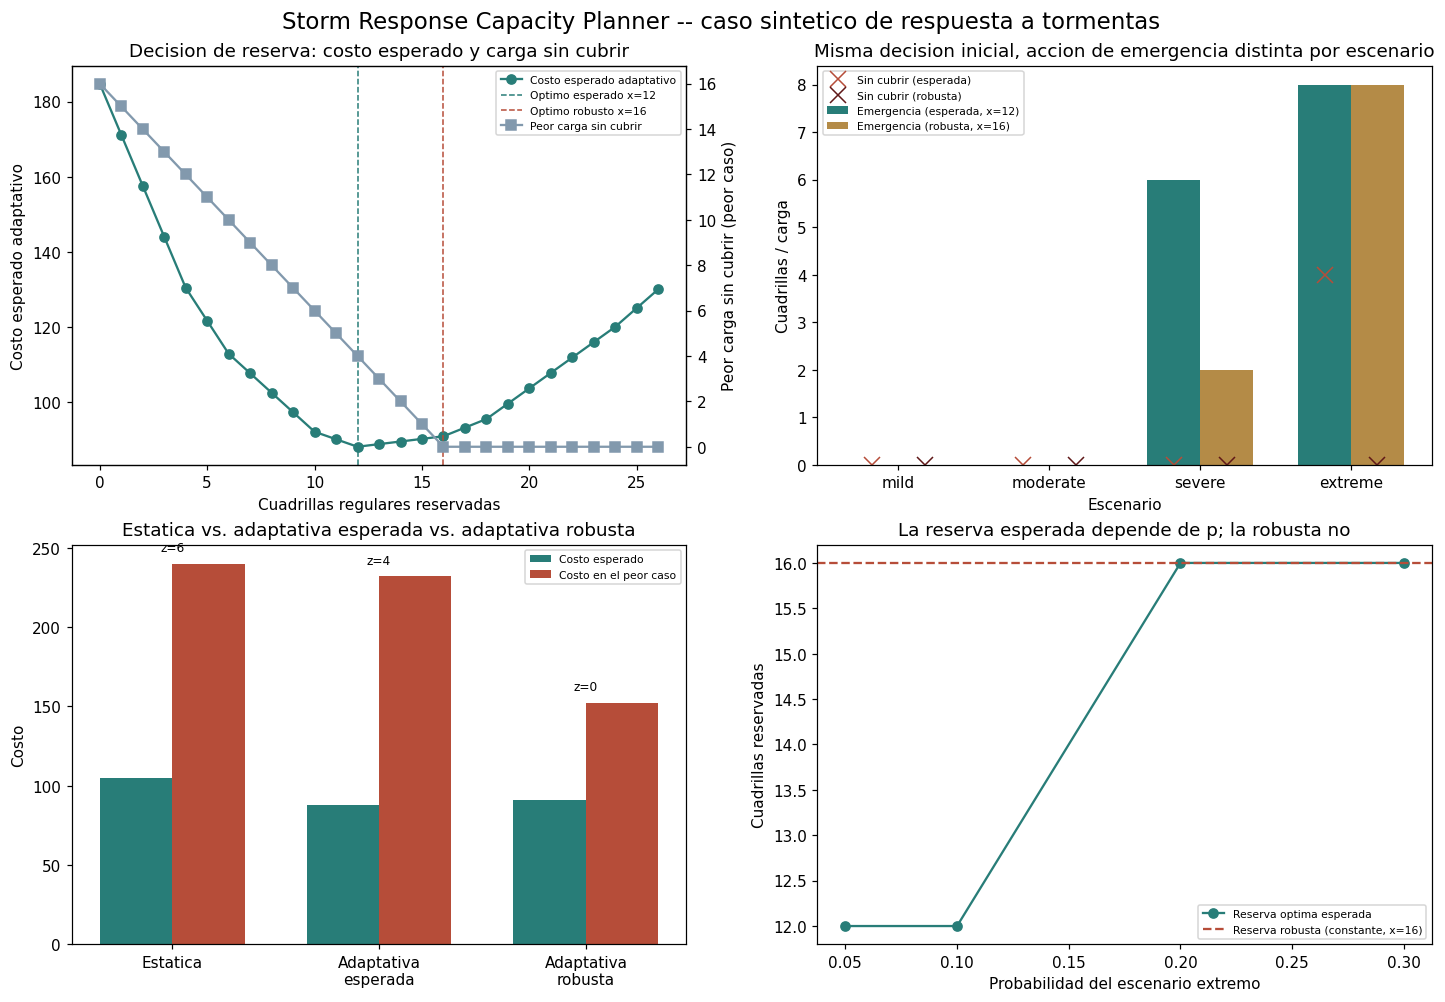

In [29]:
# El planeador completo es el producto de decision: cuantas cuadrillas reservar y como se adapta cada politica.

planner.suptitle("Storm Response Capacity Planner -- caso sintetico de respuesta a tormentas", fontsize=15)
display(planner)

In [30]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert x_expected == 12
assert x_expected_second == 13
assert np.isclose(expected_cost_opt, 88.0, atol=0.01)
assert x_static == 18
assert np.isclose(static_expected_cost_opt, 105.0, atol=0.01)
assert x_robust == 16
assert np.isclose(min_worst_unserved, 0.0)
assert np.isclose(check_15, 1.0) and np.isclose(check_16, 0.0)
assert np.isclose(absolute_savings, 17.0, atol=0.01)
assert np.isclose(percent_savings, 16.19, atol=0.1)
assert np.isclose(robust_premium_pct, 3.18, atol=0.1)
assert expected_cost_opt <= static_expected_cost_opt
assert robust_row.adaptive_expected_cost >= expected_cost_opt
assert z_rob.max() <= z_exp.max()
assert extreme_probability_sensitivity.expected_optimal_reserve.tolist() == [12, 12, 16, 16]
assert extreme_probability_sensitivity.robust_optimal_reserve.tolist() == [16, 16, 16, 16]
print("Verificado: optimos estatico, esperado y robusto consistentes; meseta de cero interrupcion confirmada; "
      "sensibilidad y prima robusta correctas.")

Verificado: optimos estatico, esperado y robusto consistentes; meseta de cero interrupcion confirmada; sensibilidad y prima robusta correctas.


In [31]:
# Guardamos la evaluacion de reserva, las acciones por escenario, la sensibilidad y el planeador; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
reserve_evaluation.to_csv(submission_dir / "reserve_evaluation.csv", index=False)
scenario_actions.to_csv(submission_dir / "scenario_actions.csv", index=False)
extreme_probability_sensitivity.to_csv(submission_dir / "extreme_probability_sensitivity.csv", index=False)
planner.savefig(submission_dir / "storm_response_capacity_planner.png", dpi=180, bbox_inches="tight", facecolor="white")
display(
    [
        str(submission_dir / name)
        for name in [
            "reserve_evaluation.csv",
            "scenario_actions.csv",
            "extreme_probability_sensitivity.csv",
            "storm_response_capacity_planner.png",
        ]
    ]
)

['../submission/reserve_evaluation.csv',
 '../submission/scenario_actions.csv',
 '../submission/extreme_probability_sensitivity.csv',
 '../submission/storm_response_capacity_planner.png']